#### Inequality Analysis – Dundee vs Scotland

##### Analytical focus
Quantify excess alcohol-related hospitalisation burden in Dundee relative to the Scottish average over time and by condition.

In [0]:
#Import python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [0]:
# Project paths

DATA_DIR = Path('../data')
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
FIGURES_DIR = Path('../figures')


#Constants
DUNDEE = 'Dundee City'
SCOTLAND = 'Scotland'

In [0]:
#load clean, analysis ready, ARHS dataset by council area

if Path('/Volumes').exists():
    PROCESSED_DIR = Path('/Volumes/group_project_wfs2025/default/arhs')
    FIGURES_DIR = PROCESSED_DIR
else:
    PROCESSED_DIR = Path('../data/processed')
    FIGURES_DIR = Path('../figures')

arhs_council_df = pd.read_csv(PROCESSED_DIR / 'ARHS_byCouncilArea_clean.csv')

arhs_council_df


,_id,condition,smr_type_code,financial_year_label,council_code,easr_stays,easr_patients,easr_new_patients,number_of_stays,number_of_patients,number_of_new_patients,average_number_of_stays_per_patient,financial_year,council_area,smr_type
0,1,All alcohol conditions,SMR01,1981/82,S92000003,156.6,138.3,0.0,7254,6435,0,1.1,1981,Scotland,Non-psychiatric
1,2,All alcohol conditions,SMR01,1982/83,S92000003,154.5,135.9,0.0,7149,6303,0,1.1,1982,Scotland,Non-psychiatric
2,3,All alcohol conditions,SMR01,1983/84,S92000003,170.0,145.8,0.0,7845,6762,0,1.2,1983,Scotland,Non-psychiatric
3,4,All alcohol conditions,SMR01,1984/85,S92000003,184.4,158.3,0.0,8577,7413,0,1.2,1984,Scotland,Non-psychiatric
4,5,All alcohol conditions,SMR01,1985/86,S92000003,207.0,176.9,0.0,9534,8190,0,1.2,1985,Scotland,Non-psychiatric
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20099,20100,Alcohol-induced pancreatitis,SMR01,2019/20,S92000003,14.5,10.5,3.4,771,558,180,1.4,2019,Scotland,Non-psychiatric
20100,20101,Alcohol-induced pancreatitis,SMR01,2020/21,S92000003,13.0,9.8,3.2,684,519,171,1.3,2020,Scotland,Non-psychiatric
20101,20102,Alcohol-induced pancreatitis,SMR01,2021/22,S92000003,13.5,9.9,3.2,708,522,171,1.4,2021,Scotland,Non-psychiatric
20102,20103,Alcohol-induced pancreatitis,SMR01,2022/23,S92000003,10.8,8.5,2.9,567,447,150,1.3,2022,Scotland,Non-psychiatric


      financial_year  easr_patients financial_year_label
7264            1997          404.6              1997/98
7296            1998          450.5              1998/99
7328            1999          522.4              1999/00
7360            2000          485.7              2000/01
7392            2001          473.2              2001/02
7424            2002          457.4              2002/03
7456            2003          458.4              2003/04
7488            2004          460.6              2004/05
7520            2005          439.3              2005/06
7552            2006          402.0              2006/07
7584            2007          423.2              2007/08
7616            2008          469.3              2008/09
7648            2009          508.2              2009/10
7680            2010          533.8              2010/11
7712            2011          452.0              2011/12
7744            2012          446.7              2012/13
7776            2013          4

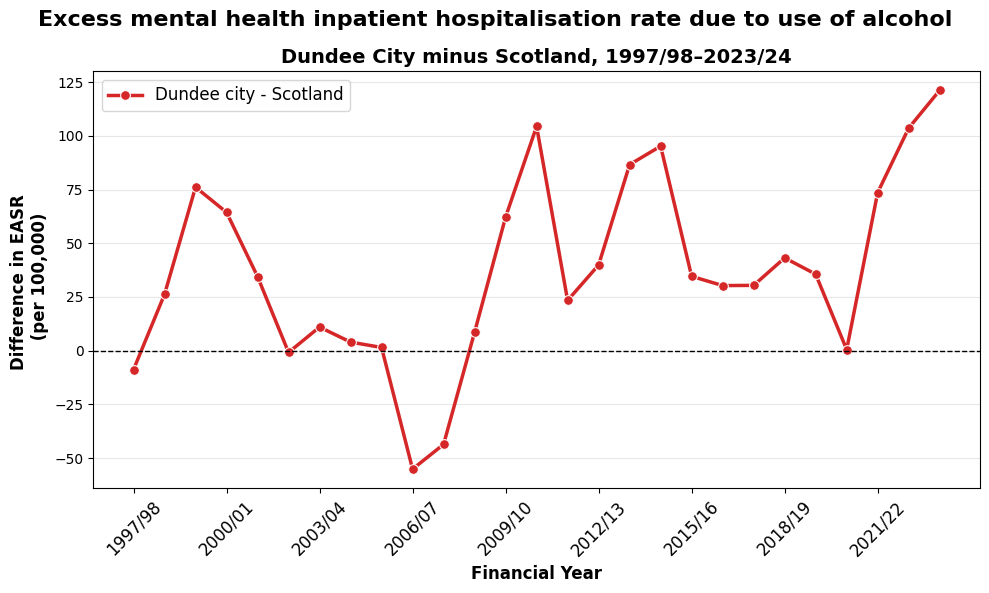

In [0]:
#Figure 5 — Excess burden (Dundee − Scotland difference over time)
#Difference in EASRPatients (Dundee minus Scotland)
#Difference line plot

#Filter dataset - Dundee only, Combined SMR, Mental & behavioural disorders due to use of alcohol: All
dundee_combined_mh_all = (
    arhs_council_df[(arhs_council_df['council_area'] == 'Dundee City')
                    & (arhs_council_df['smr_type'] == 'Combined')
                    & (arhs_council_df['condition'] == 'Mental & behavioural disorders due to use of alcohol: All')
    ]
)

print(dundee_combined_mh_all[['financial_year', 'easr_patients', 'financial_year_label']])

#Filter dataset - Scotland only, Combined SMR, Mental & behavioural disorders due to use of alcohol: All
scotland_combined_mh_all = (
    arhs_council_df[(arhs_council_df['council_area'] == 'Scotland')
                    & (arhs_council_df['smr_type'] == 'Combined')
                    & (arhs_council_df['condition'] == 'Mental & behavioural disorders due to use of alcohol: All')
    ]
)

print(scotland_combined_mh_all[['financial_year', 'easr_patients', 'financial_year_label']])

#Merge/Concatenate two dataset horizontally on 'FinancialYear' column
dundee_scotland_mh_all_diff = (
    pd.merge(
        dundee_combined_mh_all, scotland_combined_mh_all,
        on = ['financial_year', 'condition', 'smr_type'],
        suffixes = ['_Dundee', '_Scotland']
    )
)

print(dundee_scotland_mh_all_diff)

#Calculate difference between Dundee and Scotland
dundee_scotland_mh_all_diff['easr_patients_Difference'] = (
    dundee_scotland_mh_all_diff['easr_patients_Dundee'] - dundee_scotland_mh_all_diff['easr_patients_Scotland']
)

print(dundee_scotland_mh_all_diff.info())

#Plot - Difference plot (Dundee - Scotland)
fig, ax = plt.subplots(figsize = (10, 6))
custom_palette = sns.color_palette(['#d62728', '#1f77b4'])

sns.lineplot(
    data = dundee_scotland_mh_all_diff,
    x = 'financial_year',
    y = 'easr_patients_Difference',
    color = '#d62728',
    marker = 'o',
    ms = 7,
    linewidth = 2.5
)

plt.axhline(
    y = 0,
    color = 'black',
    linestyle = '--',
    linewidth = 1
)

plt.suptitle(
    'Excess mental health inpatient hospitalisation rate due to use of alcohol',
    fontsize = 16,
    weight = 'bold'
)

ax.set_title(
    'Dundee City minus Scotland, 1997/98–2023/24',
    fontsize = 14,
    weight = 'bold'
)

ax.set_xlabel(
    'Financial Year',
    fontsize = 12,
    weight = 'bold'
)

ax.set_ylabel(
    'Difference in EASR \n (per 100,000)',
    fontsize = 12,
    weight = 'bold'
)

ax.set_xticks(
    dundee_scotland_mh_all_diff['financial_year'][::3]
)

ax.set_xticklabels(
    dundee_scotland_mh_all_diff['financial_year_label_Dundee'][::3],
    rotation = 45,
    size = 12
)

ax.grid(True, axis='y', alpha=0.3)

plt.legend(
    ['Dundee city - Scotland'],
    fontsize = 12
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'ARHS_Figure5_diff_over_time.jpg',
    dpi = 300,
    bbox_inches='tight'
)

plt.show()

      smr_type financial_year_label           council_area  easr_patients
2657  Combined              2023/24          Aberdeen City          335.0
2658  Combined              2023/24          Aberdeenshire          190.2
2659  Combined              2023/24                  Angus          344.3
2660  Combined              2023/24        Argyll and Bute          439.8
2661  Combined              2023/24          East Ayrshire          375.2
2662  Combined              2023/24         North Ayrshire          469.5
2663  Combined              2023/24         South Ayrshire          361.4
2664  Combined              2023/24       Scottish Borders          224.7
2665  Combined              2023/24       Clackmannanshire          344.3
2666  Combined              2023/24  Dumfries and Galloway          330.3
2667  Combined              2023/24    East Dunbartonshire          239.5
2668  Combined              2023/24    West Dunbartonshire          554.1
2669  Combined              2023/24   

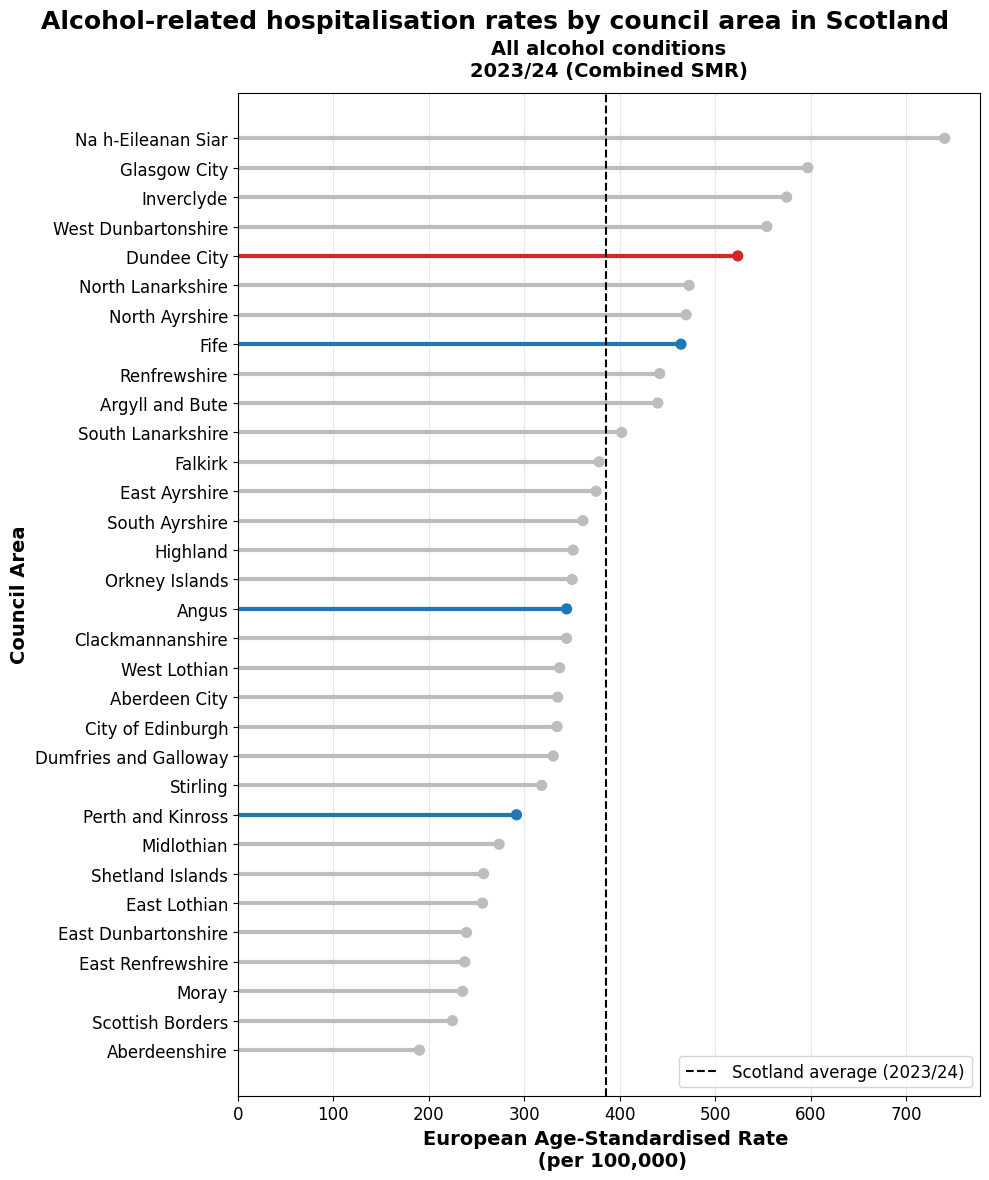

In [0]:
#Figure 6 — Council area variation in alcohol-related hospitalisations (2023/24)
#All council areas, 2023/24 only, Combined SMR
#Ranked horizontal bar chart


#Lolipop chart - compare Dundee with other regions - 2023/24

#Filter data for 2023/24 - Council Area
council_areas_2023 = arhs_council_df[
    (arhs_council_df['financial_year_label'] == '2023/24') &
    (arhs_council_df['smr_type'] == 'Combined') &
    (arhs_council_df['condition'] == 'All alcohol conditions') &
    (arhs_council_df['council_area'] != 'Scotland')
]

print(council_areas_2023[['smr_type', 'financial_year_label', 'council_area', 'easr_patients']])

#Order the list of Council Areas based on Patients Rate
council_areas_2023 = council_areas_2023.sort_values(by = 'easr_patients', ascending = True)

print(council_areas_2023[['smr_type', 'financial_year_label', 'council_area', 'easr_patients']])

#define list of colors
highlight_colors = {
    'Dundee City': '#d62728',
    'Angus': '#1f77b4',        
    'Perth and Kinross': '#1f77b4',
    'Fife': '#1f77b4'
}

default_color = '#bdbdbd'

#Create a colour column
council_areas_2023['color'] = (
    council_areas_2023['council_area']
    .map(highlight_colors)
    .fillna(default_color)
)


#Lolipop chart
fig, ax = plt.subplots(figsize = (10, 12))
    
#drawing horizontal lines
ax.hlines(
    council_areas_2023['council_area'],
    xmin = 0,
    xmax = council_areas_2023['easr_patients'],
    colors = council_areas_2023['color'],
    linewidth = 3
)

# drawing the markers (circle)
ax.scatter(
    council_areas_2023['easr_patients'],
    council_areas_2023['council_area'],
    c = council_areas_2023['color'],
    s = 50,
    zorder = 3
)

ax.set_xlim(0)

#EASRPatients Rate for Scotland

council_areas_2023_scotland = arhs_council_df[
    (arhs_council_df['financial_year_label'] == '2023/24') &
    (arhs_council_df['smr_type'] == 'Combined') &
    (arhs_council_df['condition'] == 'All alcohol conditions')
]

patient_rate_scotland_2023 = council_areas_2023_scotland[council_areas_2023_scotland['council_area'] == 'Scotland']['easr_patients'].values[0]
print(patient_rate_scotland_2023)

#Vertical line for Scotland
plt.axvline(
    patient_rate_scotland_2023,
    color = 'black',
    linestyle = '--',
    label = 'Scotland average (2023/24)'
)

plt.legend(
    loc = 'lower right',
    fontsize = 12
)

#formatting and details
fig.suptitle(
    'Alcohol-related hospitalisation rates by council area in Scotland',
    fontsize = 18,
    weight = 'bold',
    y = 0.98
)

ax.set_title(
    'All alcohol conditions\n2023/24 (Combined SMR)',
    fontsize = 14,
    pad = 12,
    weight = 'bold'
)

plt.xlabel(
    'European Age-Standardised Rate \n (per 100,000)',
    weight = 'bold',
    size = 14
)

plt.ylabel(
    'Council Area',
    weight = 'bold',
    size = 14
)

plt.xticks(size = 12)
plt.yticks(size = 12)
ax.grid(True, axis = 'x', alpha = 0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ARHS_Figure6_council_ranking.jpg', dpi = 300, bbox_inches='tight')
plt.show()

      smr_type financial_year_label           council_area  easr_patients
8084  Combined              2023/24          Aberdeen City          267.4
8085  Combined              2023/24          Aberdeenshire          137.5
8086  Combined              2023/24                  Angus          282.9
8087  Combined              2023/24        Argyll and Bute          368.5
8088  Combined              2023/24          East Ayrshire          296.2
8089  Combined              2023/24         North Ayrshire          405.3
8090  Combined              2023/24         South Ayrshire          294.3
8091  Combined              2023/24       Scottish Borders          186.6
8092  Combined              2023/24       Clackmannanshire          291.2
8093  Combined              2023/24  Dumfries and Galloway          244.9
8094  Combined              2023/24    East Dunbartonshire          203.7
8095  Combined              2023/24    West Dunbartonshire          464.0
8096  Combined              2023/24   

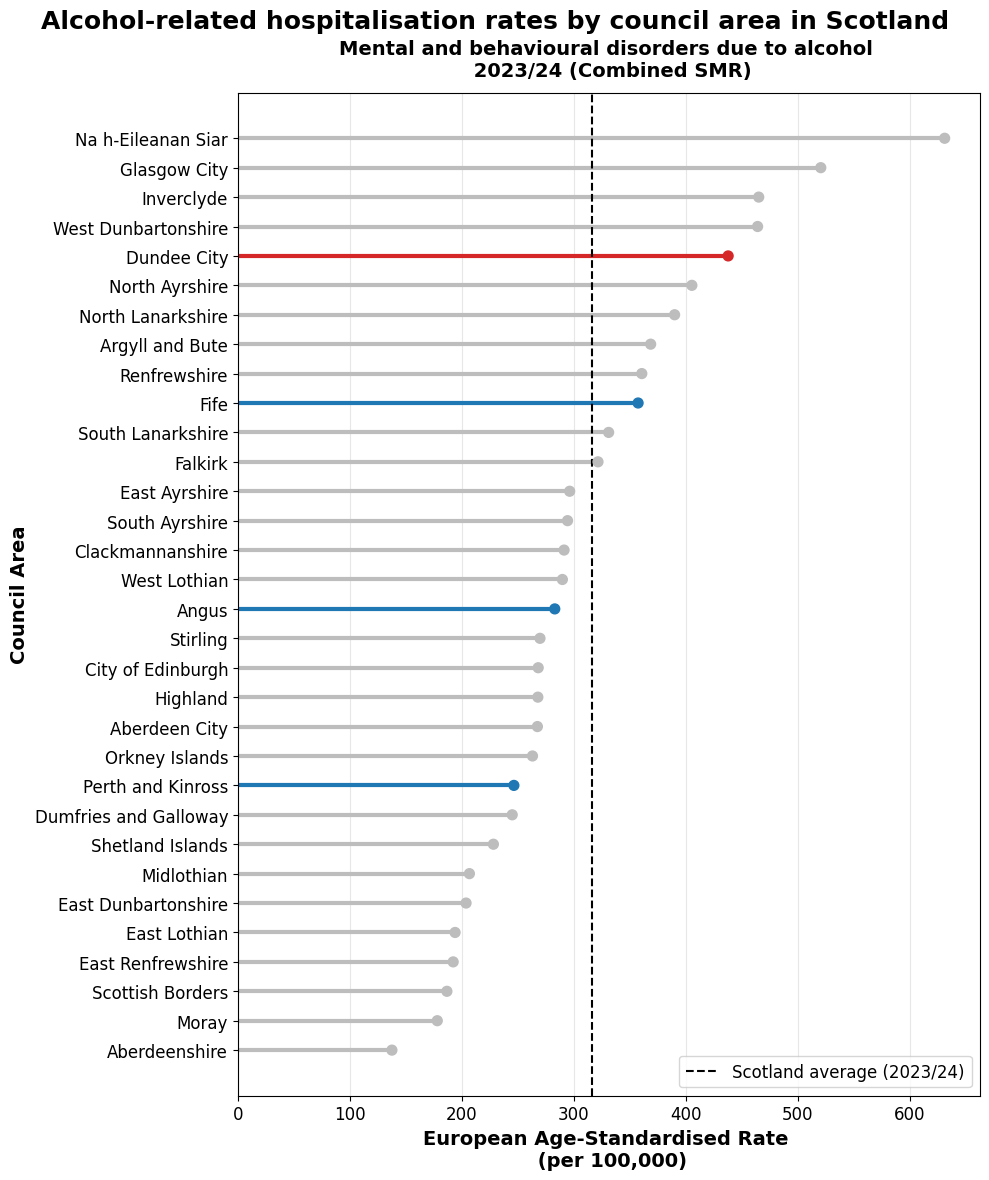

In [0]:
#Figure 7 — Council area variation: mental & behavioural disorders (2023/24)
#Same as above but clinical subgroup
#Council area MH bar plot

#Lolipop chart - compare Dundee with other regions - 2023/24

#Filter data for 2023/24 - Council Area
council_areas_mh_2023 = arhs_council_df[
    (arhs_council_df['financial_year_label'] == '2023/24') &
    (arhs_council_df['smr_type'] == 'Combined') &
    (arhs_council_df['condition'] == 'Mental & behavioural disorders due to use of alcohol: All') &
    (arhs_council_df['council_area'] != 'Scotland')
]

print(council_areas_mh_2023[['smr_type', 'financial_year_label', 'council_area', 'easr_patients']])

#Order the list of Council Areas based on Patients Rate
council_areas_mh_2023 = council_areas_mh_2023.sort_values(by = 'easr_patients', ascending = True)

print(council_areas_mh_2023[['smr_type', 'financial_year_label', 'council_area', 'easr_patients']])

#define list of colors
highlight_mh_colors = {
    'Dundee City': '#d62728',
    'Angus': '#1f77b4',        
    'Perth and Kinross': '#1f77b4',
    'Fife': '#1f77b4'
}

default_mh_color = '#bdbdbd'

#Create a colour column
council_areas_mh_2023['color'] = (
    council_areas_mh_2023['council_area']
    .map(highlight_mh_colors)
    .fillna(default_mh_color)
)


#Lolipop chart
fig, ax = plt.subplots(figsize = (10, 12))
    
#drawing horizontal lines
ax.hlines(
    council_areas_mh_2023['council_area'],
    xmin = 0,
    xmax = council_areas_mh_2023['easr_patients'],
    colors = council_areas_mh_2023['color'],
    linewidth = 3
)

# drawing the markers (circle)
ax.scatter(
    council_areas_mh_2023['easr_patients'],
    council_areas_mh_2023['council_area'],
    c = council_areas_mh_2023['color'],
    s = 50,
    zorder = 3
)

ax.set_xlim(0)

#EASRPatients Rate for Scotland

council_areas_mh_2023_scotland = arhs_council_df[
    (arhs_council_df['financial_year_label'] == '2023/24') &
    (arhs_council_df['smr_type'] == 'Combined') &
    (arhs_council_df['condition'] == 'Mental & behavioural disorders due to use of alcohol: All')
]

patient_rate_mh_scotland_2023 = council_areas_mh_2023_scotland[council_areas_mh_2023_scotland['council_area'] == 'Scotland']['easr_patients'].values[0]
print(patient_rate_mh_scotland_2023)

#Vertical line for Scotland
plt.axvline(
    patient_rate_mh_scotland_2023,
    color = 'black',
    linestyle = '--',
    label = 'Scotland average (2023/24)'
)

plt.legend(
    loc = 'lower right',
    fontsize = 12
)

#formatting and details
fig.suptitle(
    'Alcohol-related hospitalisation rates by council area in Scotland',
    fontsize = 18,
    weight = 'bold',
    y = 0.98
)

ax.set_title(
    'Mental and behavioural disorders due to alcohol \n 2023/24 (Combined SMR)',
    fontsize = 14,
    pad = 12,
    weight = 'bold'
)

plt.xlabel(
    'European Age-Standardised Rate \n (per 100,000)',
    weight = 'bold',
    size = 14
)

plt.ylabel(
    'Council Area',
    weight = 'bold',
    size = 14
)

plt.xticks(size = 12)
plt.yticks(size = 12)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'ARHS_Figure7_mh_ranking.jpg',
    dpi = 300,
    bbox_inches='tight'
)

plt.show()
